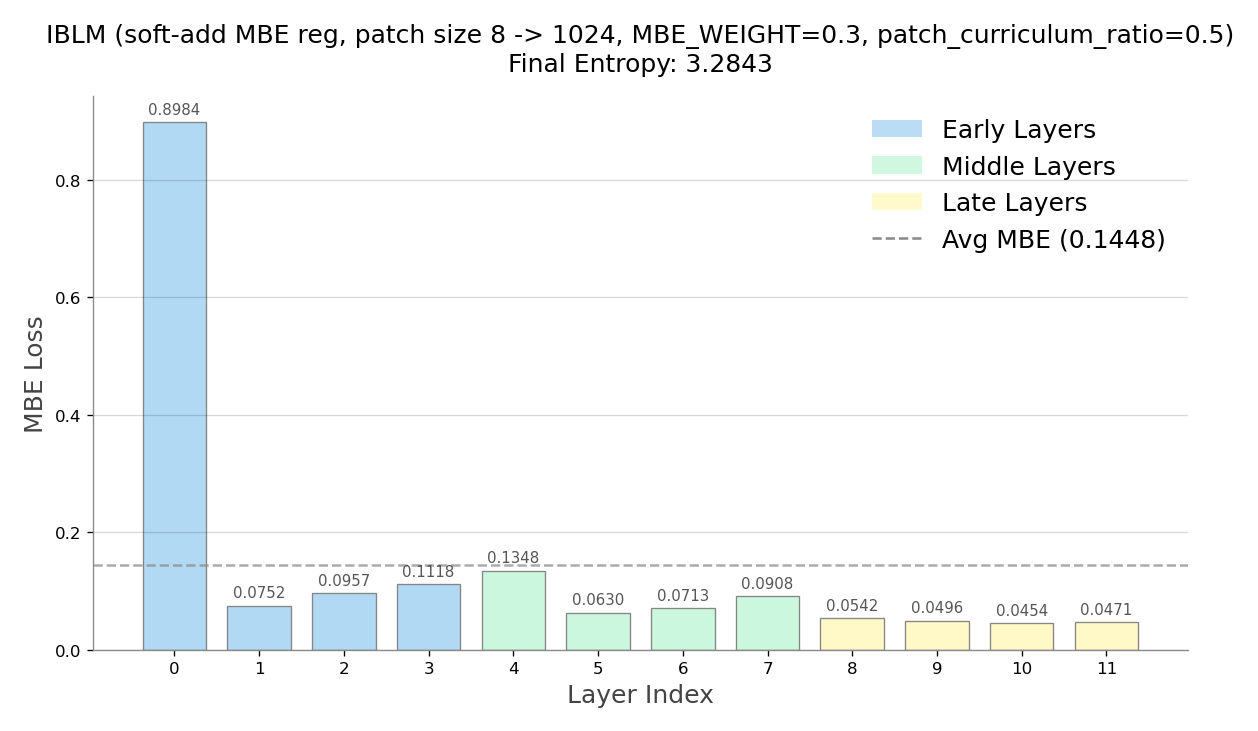

In [60]:
# Analysis on log runs 
from src.utils import *

# ----- IBLM ----- 
log_path = "logs/iblm-runs2.txt"
# log_path = "logs/iblm-fineweb10B-gpt2-small-20k.txt"

# --- extract log data ---
run_info, loss_record = extract_log_data(log_path)
n_layer = len([k for k in loss_record.keys() if 'mbe_' in k])

# --- visualize dynamics ---
frames = []
for i in range(len(loss_record["entropy"])):
    if i % 1 == 0: # Optional: skip frames for speed
        print(f"Rendering frame {i}/{len(loss_record['entropy'])}", end='\r')
        frames.append(create_training_frame(i, loss_record, run_info=run_info, n_layer=n_layer))

frames[0].save(
    f"mbe_dynamics_{run_info}.gif",
    save_all=True,
    append_images=frames[1:],
    duration=100, # ms per frame
    loop=0
)

# --- visualize final losses ---
visualize_final_losses(loss_record, run_info=run_info, n_layer=n_layer)

In [61]:
loss_record["mbe"]

[2.015625,
 0.77734375,
 0.5271809895833334,
 0.3831380208333333,
 0.3135579427083333,
 0.24658203125,
 0.193359375,
 0.14459228515625,
 0.1407470703125,
 0.14060465494791666,
 0.13873291015625,
 0.13930257161458334,
 0.14263916015625,
 0.14308675130208334,
 0.144775390625]

In [19]:
# --- Total hours required to pre-train on 10B tokens ---
tok_per_batch = (32 * 16 * 1024)
total_tok = 10 * 10**9
num_epoch = 1
steps = (num_epoch * total_tok) / tok_per_batch
ms_per_step = 5619 
total_hours = steps * ms_per_step / 1000 / 60 / 60

total_hours

29.770533243815105

In [42]:
# Issue #1. Rotation adopting 'skip_last=1' -> last few layer MBE very low
#           this is not ideal, we want mid-layer to be compressed more


In [55]:
from sorl.stat import extract_log_data

# ----- SoRL ----- 
log_path = "logs/sorl-run7.txt"

# --- extract log data ---
run_info, loss_record = extract_log_data(log_path)
n_layer = len([k for k in loss_record.keys() if 'mbe_' in k])
if "attn sweep" not in run_info:
    run_info += " + attn_sweep" 

# --- visualize dynamics --- 
# (1). x-axis: step, y-axis: search info gain, util rate, search adv, cond_traj_loss, base_traj_loss 
#     group some of them together (cond_traj_loss, base_traj_loss) (search info gain, search adv), util rate
#     3 rows 1 column, make a gif plot out
print(run_info)
{k: loss_record[k][-1]for k in loss_record}

FineWeb 2-stage info-gain SoRL (Info gain vocab compression fraction=0.5) | no orthogonal init + attn_sweep


{'base_traj_loss': 3.2821,
 'cond_traj_loss (greedy)': 3.2921,
 'cond_traj_loss (search)': 3.2921,
 'abs_loss (greedy)': 0.0019,
 'abs_loss (search)': 0.0028,
 'greedy_adv': 0.1199,
 'info_gain (greedy)': -0.003,
 'info_gain (search)': -0.003,
 'util_rate (greedy)': 0.0947,
 'util_rate (search)': 0.0949,
 'K': 8.0}

In [25]:
# from sorl.stat import generate_sorl_dynamics_gif

generate_sorl_dynamics_gif(loss_record, "2-stage-sorl-dynamics.gif", run_info, val_interval=125, fps=5)

Fixed axis limits: {'loss_min': 3.135855, 'loss_max': 11.366145, 'adv_min': -0.005, 'adv_max': 0.0235, 'info_min': -0.0164, 'info_max': 0.0157}
Generated frame 10/15
GIF saved to: 2-stage-sorl-dynamics.gif


In [56]:
val_interval = 125 

n_steps = len(loss_record.get('base_traj_loss', []))

# Precompute axis limits from ALL data
all_base = loss_record.get('base_traj_loss', [])
all_cond_greedy = loss_record.get('cond_traj_loss (greedy)', [])
all_cond_search = loss_record.get('cond_traj_loss (search)', [])
all_adv = loss_record.get('greedy_adv', [])
all_info_greedy = loss_record.get('info_gain (greedy)', [])
all_info_search = loss_record.get('info_gain (search)', [])

# Compute fixed limits from full data
loss_all = all_base + all_cond_greedy + all_cond_search
info_all = all_info_greedy + all_info_search
axis_limits = {
    'loss_min': min(loss_all) * 0.95,
    'loss_max': max(loss_all) * 1.05,
    'adv_min': min(all_adv) - 0.005,
    'adv_max': max(all_adv) + 0.005,
    'info_min': min(info_all) - 0.01,
    'info_max': max(info_all) + 0.01,
}

print(f"Fixed axis limits: {axis_limits}")

frames = []
for i in range(n_steps):
    frame = create_sorl_training_frame(i, loss_record, run_info, val_interval, axis_limits)
    frames.append(frame)
    if (i + 1) % 10 == 0:
        print(f"Generated frame {i + 1}/{n_steps}")

Fixed axis limits: {'loss_min': 3.1179949999999996, 'loss_max': 11.366145, 'adv_min': -0.005, 'adv_max': 0.13290000000000002, 'info_min': -0.017, 'info_max': 0.0071}
Generated frame 10/15


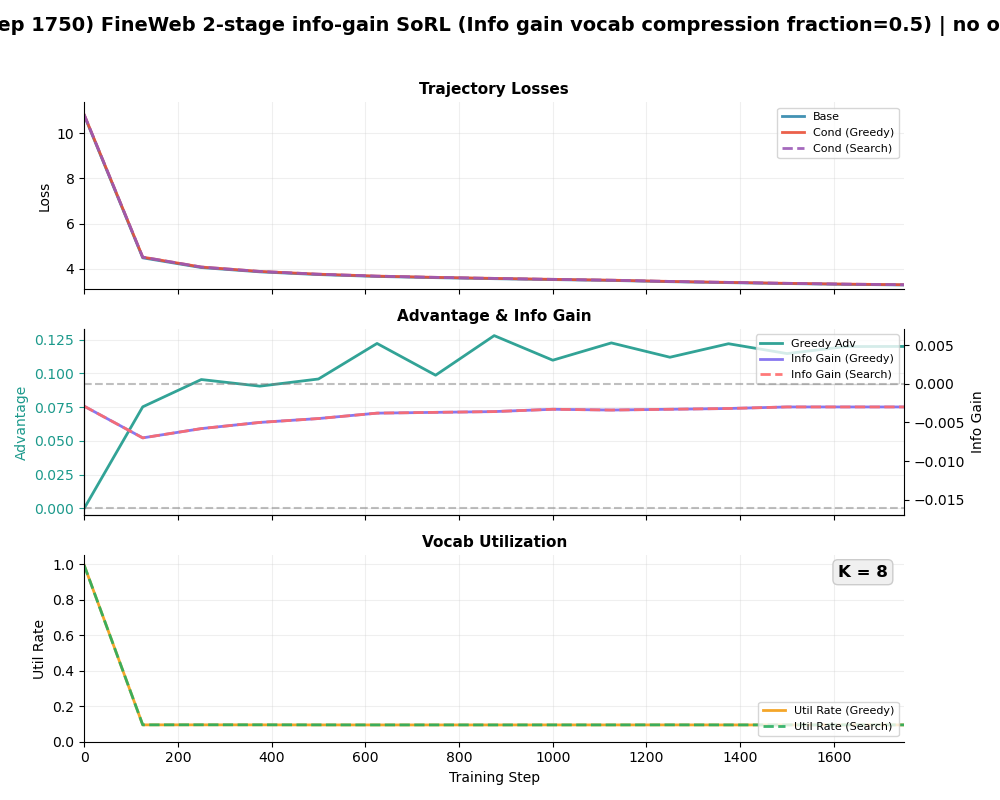

In [57]:
frame